## Key Insights

- January recorded the highest number of crashes among the months analyzed, accounting for 19.35% of all recorded crashes.

- January 18, 2020 showed an unusually high number of crashes, with the highest hourly crash count occurring at 14:00. This pattern may warrant further investigation into weather conditions and other external factors.

- Brooklyn recorded the highest number of crashes among the five boroughs, while Staten Island recorded the fewest.

- Brooklyn also recorded the highest numbers of both injuries and fatalities, with 5,872 people injured and 26 people killed. Staten Island had the lowest numbers of injuries and fatalities.

- Sedan was the most common known vehicle type recorded as Vehicle 1.

- A substantial amount of information was missing from some vehicle-related fields, particularly Vehicle 3, Vehicle 4, and Vehicle 5, which were excluded from the analysis due to their high proportion of missing values.

In [1]:
import polars as pl                      # Import the requested libraries.
from datetime import date
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
df = pl.read_csv("data/NYC Accidents 2020.csv",try_parse_dates = True)  # Load data

In [3]:
df.shape                                 # Dimensions (rows/columns) before cleaning

(74881, 29)

In [4]:
df.glimpse()                             # General information about column names/types/values.

Rows: 74881
Columns: 29
$ CRASH DATE                    <date> 2020-08-29, 2020-08-29, 2020-08-29, 2020-08-29, 2020-08-29, 2020-08-29, 2020-08-29, 2020-08-29, 2020-08-29, 2020-08-29
$ CRASH TIME                    <time> 15:40:00, 21:00:00, 18:20:00, 00:00:00, 17:10:00, 03:29:00, 19:30:00, 00:00:00, 19:50:00, 09:20:00
$ BOROUGH                        <str> 'BRONX', 'BROOKLYN', null, 'BRONX', 'BROOKLYN', null, 'BRONX', null, 'BRONX', 'QUEENS'
$ ZIP CODE                       <i64> 10466, 11221, null, 10459, 11203, null, 10459, null, 10466, 11385
$ LATITUDE                       <f64> 40.8921, 40.6905, 40.8165, 40.82472, 40.64989, 40.68231, 40.825226, 40.80016, 40.894314, 40.70678
$ LONGITUDE                      <f64> -73.83376, -73.919914, -73.946556, -73.89296, -73.93389, -73.84495, -73.88778, -73.93538, -73.86027, -73.90888
$ LOCATION                       <str> 'POINT (-73.83376 40.8921)', 'POINT (-73.919914 40.6905)', 'POINT (-73.946556 40.8165)', 'POINT (-73.89296 40.82472)', 'POI

In [5]:
df.describe()                            # Statistical summary (mean/median/min/max/std).

statistic,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
str,str,str,str,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,str,str,str,str,str
"""count""","""74881""","""74881""","""49140""",49134.0,68935.0,68935.0,"""68935""","""55444""","""35681""","""19437""",74881.0,74881.0,74881.0,74881.0,74881.0,74881.0,74881.0,74881.0,"""74577""","""59285""","""6765""","""1851""","""523""",74881.0,"""74246""","""53641""","""6425""","""1771""","""503"""
"""null_count""","""0""","""0""","""25741""",25747.0,5946.0,5946.0,"""5946""","""19437""","""39200""","""55444""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""304""","""15596""","""68116""","""73030""","""74358""",0.0,"""635""","""21240""","""68456""","""73110""","""74378"""
"""mean""","""2020-04-16 12:59:45.529039""","""13:28:49.810232""",null,10913.681585,40.689825,-73.843376,null,null,null,null,0.366555,0.001923,0.05474,0.000748,0.043709,0.00012,0.268105,0.001055,null,null,null,null,null,4.3058e6,null,null,null,null,null
"""std""",null,null,null,515.069483,1.233368,2.234881,null,null,null,null,0.726178,0.047609,0.237582,0.027337,0.209737,0.010963,0.691423,0.037073,null,null,null,null,null,21716.578974,null,null,null,null,null
"""min""","""2020-01-01""","""00:00:00""","""BRONX""",10000.0,0.0,-74.253006,"""POINT (-73.700584 40.73903)""","""1 AVENUE""","""1 AVENUE""","""00 West Drive""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Accelerator Defective""","""Aggressive Driving/Road Rage""","""Aggressive Driving/Road Rage""","""Aggressive Driving/Road Rage""","""Driver Inattention/Distraction""",4.063247e6,"""0""","""18 WEELER""","""3-Door""","""4 dr sedan""","""BOX Truck"""
"""25%""","""2020-02-10""","""09:30:00""",null,10458.0,40.667076,-73.95868,null,null,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,4.287041e6,null,null,null,null,null
"""50%""","""2020-03-23""","""14:14:00""",null,11210.0,40.716885,-73.91685,null,null,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,4.305812e6,null,null,null,null,null
"""75%""","""2020-06-28""","""18:00:00""",null,11354.0,40.78945,-73.86262,null,null,null,null,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,4.324545e6,null,null,null,null,null
"""max""","""2020-08-29""","""23:59:00""","""STATEN ISLAND""",11697.0,40.912884,0.0,"""POINT (0 0)""","""willis ave bridge""","""ï¿½ST 138 STREET""","""WEST STREET""",15.0,4.0,6.0,1.0,3.0,1.0,15.0,4.0,"""Windshield Inadequate""","""View Obstructed/Limited""","""View Obstructed/Limited""","""Unspecified""","""Unspecified""",4.343622e6,"""yellow cab""","""van""","""van""","""trailor""","""Van"""


In [6]:
df_duplicated = df.filter(df.is_duplicated())  # There are no duplicated rows in the dataset.
df_duplicated

CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
date,time,str,i64,f64,f64,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,str,str,str,str,str,i64,str,str,str,str,str


In [7]:
df["COLLISION_ID"].n_unique()     # All collision IDs are unique, so there are no duplicate collision IDs in the dataset.

74881

In [8]:
df.null_count()  # Null value counts in each column. Columns with the most null values are related to vehicle types/contributing vehicle types to the accidents.

CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,25741,25747,5946,5946,5946,19437,39200,55444,0,0,0,0,0,0,0,0,304,15596,68116,73030,74358,0,635,21240,68456,73110,74378


In [9]:
df = df.drop("LOCATION")  # Location column was removed because its coordinate information was duplicated by the separate Latitude and Longitude columns.

In [10]:
df = df.drop(["OFF STREET NAME","CONTRIBUTING FACTOR VEHICLE 3","CONTRIBUTING FACTOR VEHICLE 4","CONTRIBUTING FACTOR VEHICLE 5","VEHICLE TYPE CODE 3","VEHICLE TYPE CODE 4","VEHICLE TYPE CODE 5"])
# Drop columns that have an excessively high number of null values (>90% empty) 
# such as "vehicle type code 3, 4, 5" and "contributing factor vehicle 3,4,5", 
# as well as "off street name" which is mostly empty (~73% null) 
# since the main "on street name" column is already available and provides sufficient location data.

In [11]:
df = df.drop_nulls(["LATITUDE","LONGITUDE","BOROUGH"]) # Rows with missing "LATITUDE" and "LONGITUDE" were dropped, as filling them would distort the dataset and render them useless for spatial analysis.

In [12]:
df.shape    # After cleaning

(47746, 21)

In [13]:
df = df.with_columns(
    pl.col(["ON STREET NAME","CROSS STREET NAME"]).fill_null("UNKNOWN"),
    pl.col(["CONTRIBUTING FACTOR VEHICLE 1","CONTRIBUTING FACTOR VEHICLE 2"]).fill_null("Unspecified"),
    pl.col(["VEHICLE TYPE CODE 1","VEHICLE TYPE CODE 2"]).fill_null("Unknown")
)
# Changed null values to "Unknown" and "Unspecified" according to the values in columns, since dropping them would affect the analysis.

In [14]:
df = df.with_columns(
    pl.col(["VEHICLE TYPE CODE 1","VEHICLE TYPE CODE 2"]).str.to_uppercase()
)

In [15]:
df = df.with_columns(
    pl.col("CRASH DATE").dt.month().alias("MONTH NUMBER"),
    pl.col("CRASH DATE").dt.strftime("%B").alias("MONTH")
)
# Added new columns named MONTH and MONTH NUMBER for future use in a line chart.

In [16]:
df.group_by("CRASH DATE").agg(
    pl.col("BOROUGH").count().alias("COUNT")
).sort("COUNT", descending = True)
# The date with the most accidents is 18 January 2020 with 494 accidents in total.

CRASH DATE,COUNT
date,u32
2020-01-18,494
2020-03-06,434
2020-02-14,396
2020-02-07,386
2020-02-10,381
…,…
2020-04-13,68
2020-04-12,64
2020-04-19,60


In [17]:
df["NUMBER OF PERSONS KILLED"].sum()   # 70 people died in the recorded crashes.

70

In [18]:
df["NUMBER OF PERSONS KILLED"].max()  # Maximum number of people died in one accident.

3

In [19]:
pivot1 = df.pivot(
    on = "BOROUGH",
    index = "CRASH DATE",
    values = "CRASH DATE",
    aggregate_function = "len"
)
pivot1.filter(
    pl.col("CRASH DATE") == date(2020,1,18)
)
# Queens was the borough with the most accidents that day, with 177 accidents, but fortunately, no one died as a result.
# The high number of crashes on January 18 may warrant further investigation into weather conditions and other external factors.

CRASH DATE,BRONX,BROOKLYN,QUEENS,MANHATTAN,STATEN ISLAND
date,u32,u32,u32,u32,u32
2020-01-18,96,149,177,57,15


In [20]:
df.filter(
    (pl.col("CRASH DATE") == date(2020,1,18)) & (pl.col("NUMBER OF PERSONS KILLED") > 1)
) 

CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,ON STREET NAME,CROSS STREET NAME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,MONTH NUMBER,MONTH
date,time,str,i64,f64,f64,str,str,i64,i64,i64,i64,i64,i64,i64,i64,str,str,i64,str,str,i8,str


In [21]:
df2 = (
    df.filter(pl.col("CRASH DATE") == date(2020, 1, 18))
    .group_by("CRASH TIME")
    .agg(pl.col("BOROUGH").count())
    .sort("BOROUGH", descending=True)
)
df2
# The number of accidents peaked at 14:00 in January 18, 2020 with 18 accidents during that time.

CRASH TIME,BOROUGH
time,u32
14:00:00,18
13:30:00,14
13:00:00,12
18:00:00,12
17:30:00,11
…,…
14:58:00,1
18:47:00,1
03:50:00,1


In [22]:
df.group_by("MONTH").agg(
    pl.col("CRASH DATE").count().alias("COUNT")).with_columns(
    (pl.col("COUNT")/pl.col("COUNT").sum()* 100).round(2).alias("PERCENT OF TOTAL") 
).sort("COUNT", descending = True)
# January is the month with the most accidents.
# Accidents in January accounted for 19.35% of all reported accidents.
# Most accidents occured in winter season.

MONTH,COUNT,PERCENT OF TOTAL
str,u32,f64
"""January""",9240,19.35
"""February""",8740,18.31
"""March""",7037,14.74
"""July""",5962,12.49
"""August""",5530,11.58
"""June""",4886,10.23
"""May""",3838,8.04
"""April""",2513,5.26


In [23]:
line_chart = df.group_by(["MONTH NUMBER","MONTH"]).agg(
    pl.col("CRASH DATE").count().alias("COUNT")
).sort("MONTH NUMBER", descending = False)
line_chart

MONTH NUMBER,MONTH,COUNT
i8,str,u32
1,"""January""",9240
2,"""February""",8740
3,"""March""",7037
4,"""April""",2513
5,"""May""",3838
6,"""June""",4886
7,"""July""",5962
8,"""August""",5530


In [34]:
bar_chart = df.group_by("BOROUGH").agg(
    pl.col("CRASH DATE").count().alias("COUNT")
).sort("COUNT", descending = True)
bar_chart
# The borough with the most accidents is Brooklyn and the borough with the least accidents is Staten Island.

BOROUGH,COUNT
str,u32
"""BROOKLYN""",16527
"""QUEENS""",13652
"""BRONX""",9068
"""MANHATTAN""",7104
"""STATEN ISLAND""",1395


In [36]:
bar_chart1 = df.group_by("BOROUGH").agg(
    pl.col("NUMBER OF PERSONS KILLED").sum().alias("KILLED"),
    pl.col("NUMBER OF PERSONS INJURED").sum().alias("INJURED")
).sort("INJURED", descending = True)
bar_chart1
# Brooklyn recorded the highest numbers of both injuries and fatalities, while Staten Island recorded the lowest number of injuries and fatalities.

BOROUGH,KILLED,INJURED
str,i64,i64
"""BROOKLYN""",26,5872
"""QUEENS""",19,4481
"""BRONX""",10,3094
"""MANHATTAN""",9,2090
"""STATEN ISLAND""",6,598


In [26]:
df["VEHICLE TYPE CODE 1"].value_counts().sort("count", descending = True)
# Sedans are the most common known vehicle type involved in crashes, appearing most frequently as Vehicle 1 and Vehicle 2.

VEHICLE TYPE CODE 1,count
str,u32
"""SEDAN""",21815
"""STATION WAGON/SPORT UTILITY VE…",17585
"""TAXI""",1783
"""PICK-UP TRUCK""",1196
"""BOX TRUCK""",902
…,…
"""FREIGHT TR""",1
"""GEN AMBUL""",1
"""G COM""",1


In [27]:
df["VEHICLE TYPE CODE 2"].value_counts().sort("count", descending = True)
# A substantial number of Vehicle 2 records have an Unknown vehicle type.

VEHICLE TYPE CODE 2,count
str,u32
"""UNKNOWN""",14688
"""SEDAN""",13871
"""STATION WAGON/SPORT UTILITY VE…",11450
"""BIKE""",1638
"""BOX TRUCK""",1029
…,…
"""18 WEELER""",1
"""PICK UP TR""",1
"""ACCESS A R""",1


**Note on CONTRIBUTING FACTOR columns:** 
CONTRIBUTING FACTOR VEHICLE 2 was excluded 
from further analysis, as approximately 87% of its values were either "Unspecified" 
(66.6%) or missing (20.8%), leaving little meaningful information to analyze.

In [37]:
factor1 = df.filter(
    pl.col("CONTRIBUTING FACTOR VEHICLE 1") != "Unspecified"
)["CONTRIBUTING FACTOR VEHICLE 1"].value_counts().sort("count", descending = True)
factor1
# Excluding "Unspecified", Driver Inattention/Distraction is by far the most common 
# known contributing factor for Vehicle 1, accounting for 11,900 crashes.

CONTRIBUTING FACTOR VEHICLE 1,count
str,u32
"""Driver Inattention/Distraction""",11900
"""Failure to Yield Right-of-Way""",3312
"""Backing Unsafely""",2197
"""Following Too Closely""",2127
"""Passing Too Closely""",1866
…,…
"""Using On Board Navigation Devi…",4
"""Cell Phone (hands-free)""",4
"""Tow Hitch Defective""",4


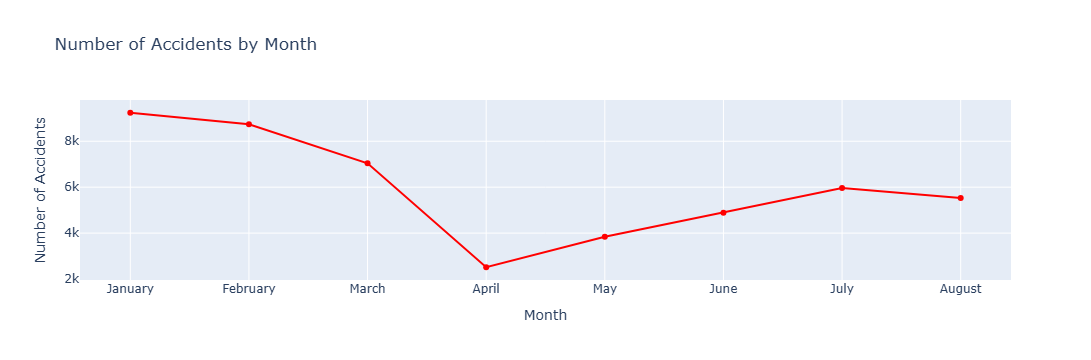

In [38]:
fig = px.line(
    line_chart,
    x = "MONTH",
    y = "COUNT",
    markers = True,
    title = "Number of Accidents by Month",
    color_discrete_sequence = ["red"],
    labels = {
        "MONTH" : "Month",
        "COUNT": "Number of Accidents"
    }
)
fig.update_layout(plot_bgcolor = "light gray")
fig.show()

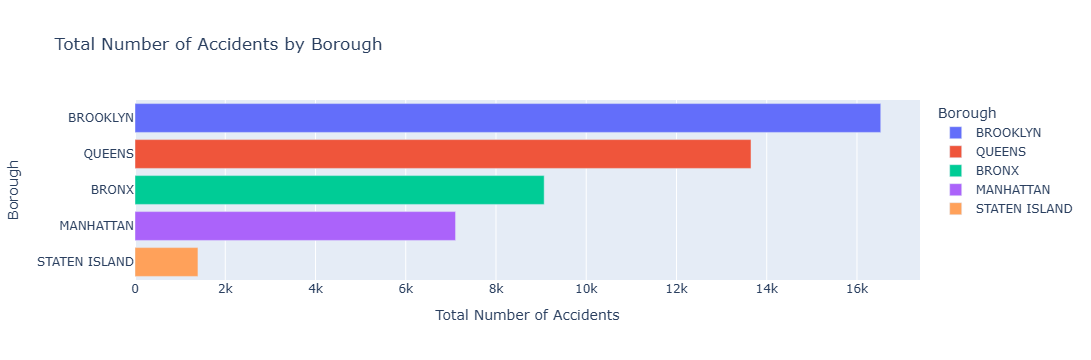

In [35]:
fig = px.bar(
    bar_chart,
    x = "COUNT",
    y = "BOROUGH",
    color = "BOROUGH",
    title = "Total Number of Accidents by Borough",
    labels = {
    "BOROUGH" : "Borough",
    "COUNT" : "Total Number of Accidents"
    }
)
fig.show()

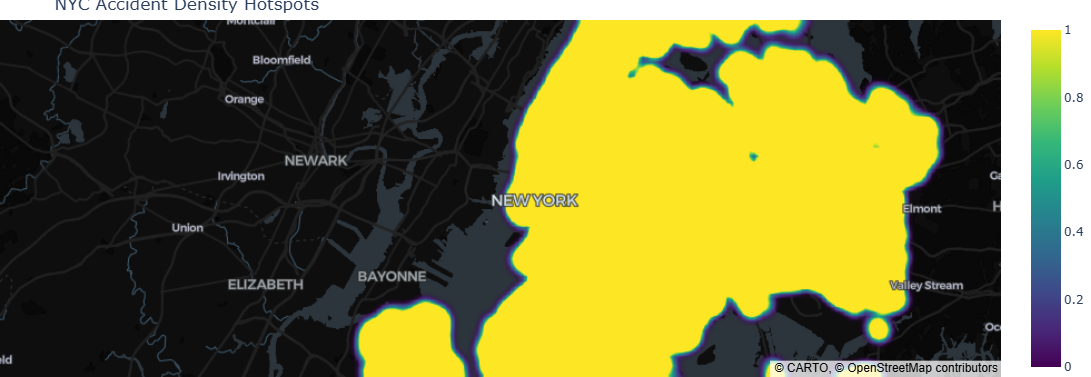

In [31]:
fig = px.density_map(
    df,
    lat = "LATITUDE",
    lon = "LONGITUDE",         
    radius = 15,
    color_continuous_scale = "Viridis",
    zoom = 10,
    center = dict(lat = 40.7128, lon = -74.0060), 
    title = "NYC Accident Density Hotspots"
)
fig.update_layout(
    map_style = "carto-darkmatter", 
    margin = {"r": 0,"t": 20,"l": 0,"b": 0}
)

fig.show()

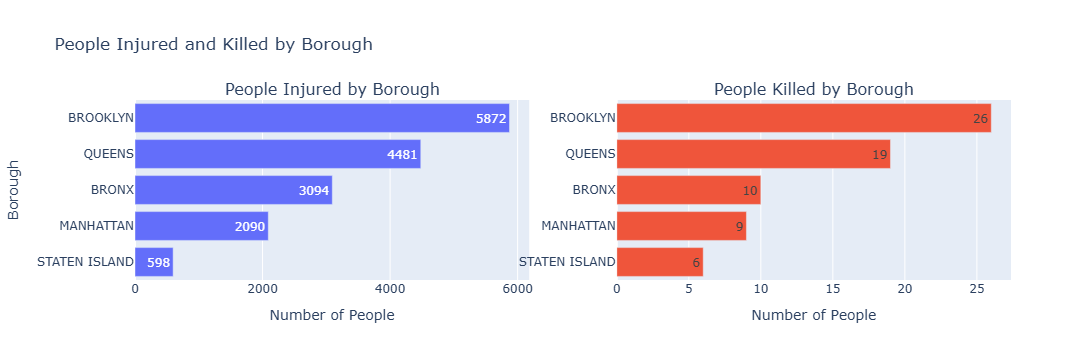

In [32]:
bar_chart1 = bar_chart1.sort("KILLED", descending = False)
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "People Injured by Borough",
        "People Killed by Borough"
    )
)

# Injured
fig.add_trace(
    go.Bar(
        x = bar_chart1["INJURED"],
        y = bar_chart1["BOROUGH"],
        orientation = "h",
        name = "Injured",
        text = bar_chart1["INJURED"],
        textposition = "auto"
    ),
    row=1,
    col=1
)
# Killed
fig.add_trace(
    go.Bar(
        x = bar_chart1["KILLED"],
        y = bar_chart1["BOROUGH"],
        orientation = "h",
        name = "Killed",
        text = bar_chart1["KILLED"],
        textposition = "auto"
    ),
    row=1,
    col=2
)

fig.update_layout(
    title="People Injured and Killed by Borough",
    showlegend=False
)

fig.update_xaxes(title_text="Number of People", row=1, col=1)
fig.update_xaxes(title_text="Number of People", row=1, col=2)

fig.update_yaxes(title_text="Borough", row=1, col=1)
fig.update_yaxes(title_text="", row=1, col=2)
fig.show()

## Conclusion

Overall, the analysis revealed clear differences in crash frequency, injuries, and fatalities across NYC boroughs and over time. Brooklyn had the highest overall crash, injury, and fatality counts, while January recorded the highest number of crashes among the months analyzed. The analysis also highlighted substantial missing information in some vehicle-related fields, which should be considered when interpreting the results.